# Hodge decomposition on a stellarator

Tangential vector field decomposition

$$f = \nabla_\Gamma u + n \times \nabla_\Gamma v + w.$$


In [1]:
from pathlib import Path
import sys

project = Path.cwd().resolve()
if project.name == 'notebooks':
    project = project.parent
sys.path.insert(0, str(project))

import pysurfacefun as psf

output_dir = project / 'notebook_outputs'
output_dir.mkdir(exist_ok=True)

## Build the Stellarator Surface

Small test parameters:

In [2]:
n = 20
nu = 6
nv = 12

dom = psf.stellarator(n=n, nu=nu, nv=nv)
print(f'patches      = {dom.npatches}')
print(f'grid/patch   = {dom.n} x {dom.n}')
print(f'surface area = {psf.surfacearea(dom):.12f}')

patches      = 72
grid/patch   = 20 x 20
surface area = 178.080605766975


To try the high-resolution experiment later, use:

```python
n = 20
nu = 8
nv = 24
dom = psf.stellarator(n=n, nu=nu, nv=nv)
```

This will be expensive in the current Python version.

## Construct the Vector Field

The field starts as a smooth ambient vector field and is then projected tangentially onto the surface.

In [7]:
x0 = 0.2
y0 = 0.2
z0 = 0.2

def denom(x, y, z):
    return ((x - x0)**2 + (y - y0)**2 + (z - z0)**2)**1.5

G = psf.vector_field(
    lambda x, y, z: (x - x0) / denom(x, y, z),
    lambda x, y, z: (y - y0) / denom(x, y, z),
    lambda x, y, z: (z - z0) / denom(x, y, z),
    dom,
)

V = psf.cross([0, 1, 1], G)
vn = psf.normal(dom)
f = -psf.cross(vn, vn, V)

print(f'||f||_inf = {psf.norm(f, "inf"):.6e}')
print(f'||n dot f||_inf = {psf.norm(psf.dot(vn, f), "inf"):.3e}')

||f||_inf = 1.497783e-01
||n dot f||_inf = 2.602e-17


## Hodge Decomposition

The decomposition is computed from two scalar surface Poisson problems:

$$\Delta_\Gamma u = \operatorname{div}_\Gamma f,$$

$$\Delta_\Gamma v = -\operatorname{div}_\Gamma(n \times f),$$

$$w = f - \nabla_\Gamma u - n \times \nabla_\Gamma v.$$

In [4]:
u, v, w, curlfree, divfree = psf.hodge(f)

reconstruction = f - curlfree - divfree - w
print(f'||curlfree||_inf       = {psf.norm(curlfree, "inf"):.6e}')
print(f'||divfree||_inf        = {psf.norm(divfree, "inf"):.6e}')
print(f'||harmonic||_inf       = {psf.norm(w, "inf"):.6e}')
print(f'||reconstruction||_inf = {psf.norm(reconstruction, "inf"):.3e}')
print(f'||div(divfree)||_inf   = {psf.norm(psf.div(divfree), "inf"):.3e}')

||curlfree||_inf       = 9.087126e-02
||divfree||_inf        = 5.541351e-02
||harmonic||_inf       = 7.393037e-02
||reconstruction||_inf = 0.000e+00
||div(divfree)||_inf   = 2.472e-04


## Optional Plots

These require `matplotlib`. The color is the vector magnitude, and the arrows show normalized vector direction.

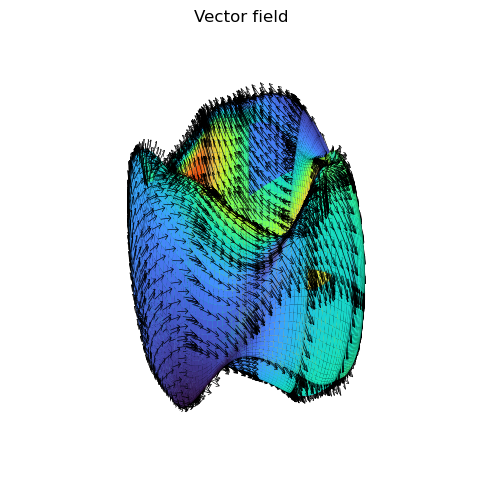

/Users/gentianzavalani/Downloads/pysurfacefun-main_1/pysurfacefun/core.py:1979: ComplexWarning: Casting complex values to real discards the imaginary part
  vmin = min(float(np.min(v)) for v in mag.vals)
/Users/gentianzavalani/Downloads/pysurfacefun-main_1/pysurfacefun/core.py:1980: ComplexWarning: Casting complex values to real discards the imaginary part
  vmax = max(float(np.max(v)) for v in mag.vals)
/Users/gentianzavalani/anaconda3/envs/minterpy/lib/python3.11/site-packages/matplotlib/colors.py:728: ComplexWarning: Casting complex values to real discards the imaginary part
  xa = xa.astype(int)
/Users/gentianzavalani/anaconda3/envs/minterpy/lib/python3.11/site-packages/mpl_toolkits/mplot3d/axes3d.py:2615: ComplexWarning: Casting complex values to real discards the imaginary part
  UVW = np.column_stack(input_args[3:]).astype(float)


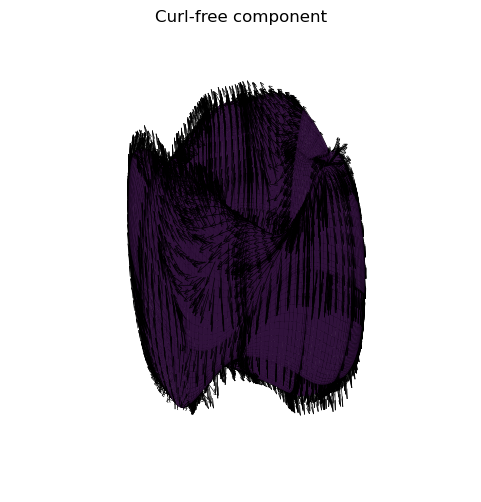

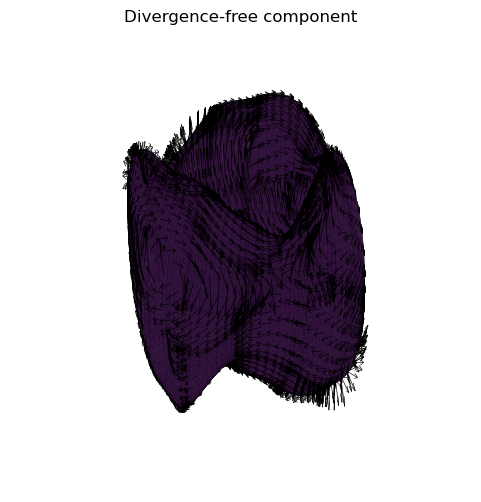

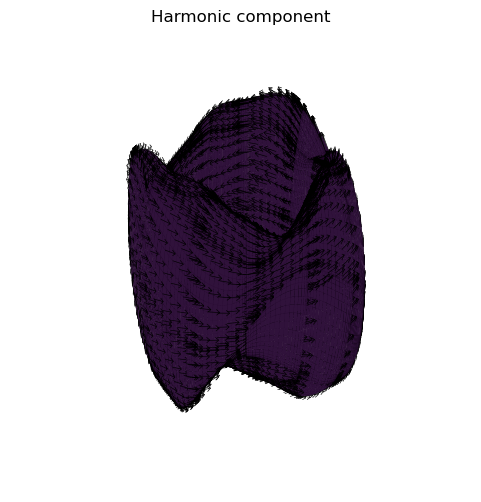

In [5]:
try:
    %matplotlib inline
    psf.plot_vector_field(f, title='Vector field', stride=2, scale=0.5)
    psf.plot_vector_field(curlfree, title='Curl-free component', stride=2, scale=0.5)
    psf.plot_vector_field(divfree, title='Divergence-free component', stride=2, scale=0.5)
    psf.plot_vector_field(w, title='Harmonic component', stride=2, scale=0.5)
except Exception as exc:
    print('plot skipped:', exc)

## Optional VTU Export

The current VTU writer exports scalar surface functions. Here we export vector magnitudes.

In [6]:
try:
    psf.write_vtu(output_dir / 'hodge_vector_field_norm.vtu', psf.vector_norm(f), point_name='norm_f')
    psf.write_vtu(output_dir / 'hodge_curlfree_norm.vtu', psf.vector_norm(curlfree), point_name='norm_curlfree')
    psf.write_vtu(output_dir / 'hodge_divfree_norm.vtu', psf.vector_norm(divfree), point_name='norm_divfree')
    psf.write_vtu(output_dir / 'hodge_harmonic_norm.vtu', psf.vector_norm(w), point_name='norm_harmonic')
    print('wrote Hodge component norm VTU files')
except Exception as exc:
    print('VTU export skipped:', exc)

VTU export skipped: dtype('complex128')
